# Agglomerative:

## 1. Calcualte Distance
### Measure distance between all existing cluster

## 2. Find the Closet Pair
### Identify the two cluster nearset to each other

## 3. Merrge Them
### Combine into one large cluster

## 4.Repeat
### Continue until only 1 gaint cluster remains

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("Mall_Customers.csv")

In [4]:
q1 = 41.500000
q3 = 78.000000

iqr = q3-q1

In [5]:
ub = q3 + (iqr*1.5)
lb = q1 - (iqr*1.5)

In [6]:
df = df[(df["Annual Income (k$)"]>=lb)&(df["Annual Income (k$)"]<=ub)]

In [7]:
from sklearn.preprocessing import LabelEncoder

In [8]:
le = LabelEncoder()

In [9]:
df["Genre"] = le.fit_transform(df["Genre"])

In [10]:
x = df[["Annual Income (k$)","Spending Score (1-100)"]]

In [13]:
    from sklearn.preprocessing import MinMaxScaler

In [14]:
minMax = MinMaxScaler()

In [15]:
x = minMax.fit_transform(x)

In [20]:
from scipy.cluster.hierarchy import linkage

In [18]:
import scipy.cluster.hierarchy as sch

In [21]:
z= linkage(x,method="complete",metric="euclidean")

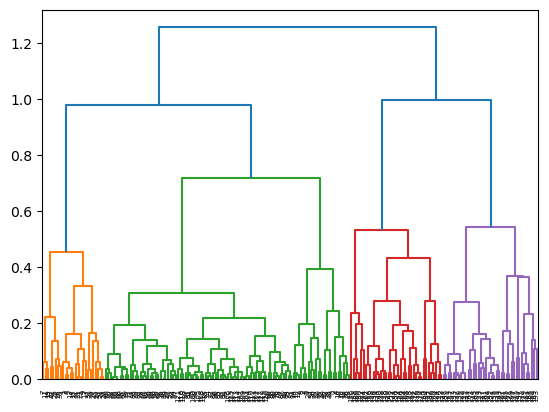

In [23]:
sch.dendrogram(z)
plt.show()

In [25]:
from sklearn.cluster import AgglomerativeClustering

In [26]:
h_complete = AgglomerativeClustering(n_clusters=5,linkage="complete")

In [27]:
h_complete.fit(x)

,n_clusters,5
,metric,'euclidean'
,memory,None
,connectivity,None
,compute_full_tree,'auto'
,linkage,'complete'
,distance_threshold,None
,compute_distances,False


In [30]:
df["labels"]=h_complete.labels_

<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

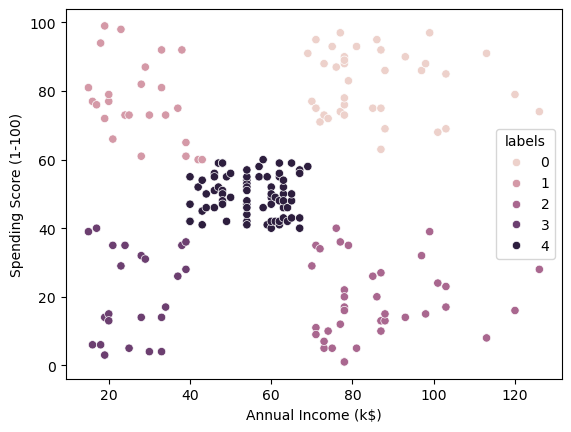

In [32]:
sns.scatterplot(data=df,x="Annual Income (k$)",y="Spending Score (1-100)",hue="labels")

In [31]:
df.describe()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),labels
count,198.000000,198.000000,198.000000,198.000000,198.000000,198.000000
mean,99.500000,0.434343,38.929293,59.787879,50.196970,2.363636
std,57.301832,0.496927,14.016852,25.237259,25.746846,1.550861
min,1.000000,0.000000,18.000000,15.000000,1.000000,0.000000
25%,50.250000,0.000000,28.250000,40.500000,35.000000,1.000000
50%,99.500000,0.000000,36.000000,61.000000,50.000000,2.000000
75%,148.750000,1.000000,49.000000,77.750000,72.750000,4.000000
max,198.000000,1.000000,70.000000,126.000000,99.000000,4.000000
